# **02 - Exploratory Analysis**

**Summary**

This notebook explores variation in respiratory hospital admissions using cleaned, spell-level data from the synthetic HES extract (`apc_clean.parquet`).

Four inferential comparisons were performed to assess potential differences in patient or admission characteristics across clinical and deprivation groupings.

**Key obervations**

- **Length of Stay** shows the clearest clinical signal. COPD and pneumonia are associated with longer hospital stays compared to asthma and other conditions.  
  This is consistent with real-world patterns and validates the data processing workflow.

- **Age distribution** and **emergency admission proportions** show no meaningful variation by diagnosis.  
  This likely reflects the synthetic design, where age and admission method are not tightly linked to condition codes.

- **Repeat admissions** are rare overall (mean 1.13 per patient), producing a statistically detectable but practically small difference by deprivation quintile.

**Interpretation**

Overall, the EDA highlights clinically plausible variation in length of stay by respiratory group but limited evidence of strong inequality effects at the spell level.

**Note on time coverage:**  
This dataset spans 2018–2021 and includes the COVID-19 period, which disrupted admission patterns nationally. Sharp dips in early 2020 and rebounds in 2021 reflect pandemic-related service changes rather than true respiratory demand.

Model outputs going forwards should therefore be interpreted with caution for general use.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, chi2_contingency

In [26]:
# Load cleaned data
df = pd.read_parquet("../data/processed/apc_clean.parquet")
df.shape

(145246, 16)

In [27]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145246 entries, 0 to 145245
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   patient_id         145246 non-null  object        
 1   adm                145246 non-null  datetime64[ns]
 2   dis                145246 non-null  datetime64[ns]
 3   n_episodes         145246 non-null  int64         
 4   los_days           145246 non-null  float64       
 5   any_emerg          145246 non-null  bool          
 6   imd_quintile       142454 non-null  Int8          
 7   primary_diag       145246 non-null  object        
 8   ethnicity          145246 non-null  category      
 9   sex                145246 non-null  category      
 10  age                145246 non-null  Int16         
 11  spell_id           145246 non-null  string        
 12  ethnicity_group    145246 non-null  category      
 13  age_band_quinary   145246 non-null  category

In [28]:
df.describe()

,adm,dis,n_episodes,los_days,imd_quintile,age
count,145246,145246,145246.000000,145246.000000,142454.0,145246.0
mean,2020-03-28 16:31:47.296586496,2020-06-22 18:20:01.900224768,1.000110,8.707517,2.884854,55.314969
min,2018-07-11 00:00:00,2019-04-01 00:00:00,1.000000,0.100000,1.0,1.0
25%,2019-06-05 00:00:00,2019-10-16 00:00:00,1.000000,0.200000,2.0,35.0
50%,2020-04-26 00:00:00,2020-06-26 00:00:00,1.000000,5.300000,3.0,58.0
75%,2021-04-02 00:00:00,2021-04-12 00:00:00,1.000000,14.900000,4.0,74.0
max,2021-06-25 00:00:00,2021-06-30 00:00:00,2.000000,36.500000,5.0,120.0
std,NaN,NaN,0.010495,9.246392,1.406824,25.330795


In [29]:
# Checks
print("Min adm date: ", df["adm"].min())
print("Max adm date: ", df["adm"].max())
print(df["respiratory_group"].value_counts(normalize=True))

Min adm date:  2018-07-11 00:00:00
Max adm date:  2021-06-25 00:00:00
respiratory_group
Other respiratory    0.451042
Pneumonia            0.330446
COPD                 0.153361
Asthma               0.065152
Name: proportion, dtype: float64


Text(0.5, 0, 'Admission Date')

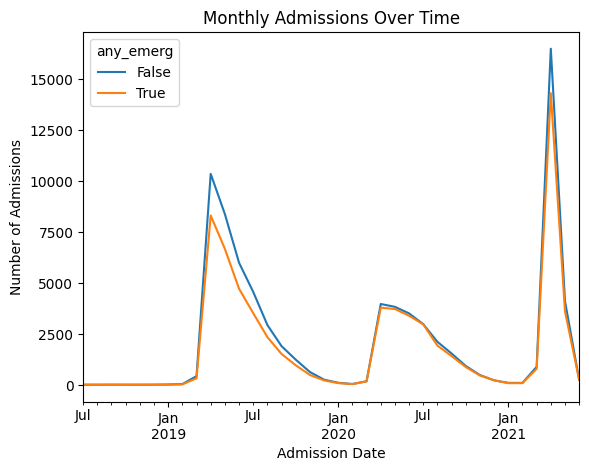

In [30]:
# Admissions trends
df["month"] = df["adm"].dt.to_period("M")

admissions_trend = (
    df
    .groupby(["month", "any_emerg"], observed=False)["spell_id"]
    .count()
    .unstack("any_emerg", fill_value=0)
)

admissions_trend.plot(title="Monthly Admissions Over Time")

plt.ylabel("Number of Admissions")
plt.xlabel("Admission Date")

In [31]:
admissions_trend.head()

any_emerg,False,True
month,,
2018-07,0,2
2018-08,0,1
2018-09,2,1
2018-10,1,0
2018-11,0,2


Text(0.5, 1.0, 'Length of Stay Distribution')

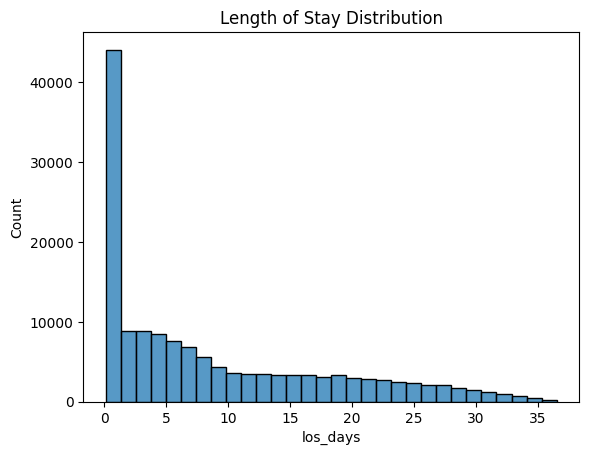

In [32]:
# LOS histogram 
sns.histplot(df["los_days"].dropna(), bins=30)

plt.title("Length of Stay Distribution")

<Axes: xlabel='imd_quintile', ylabel='pct'>

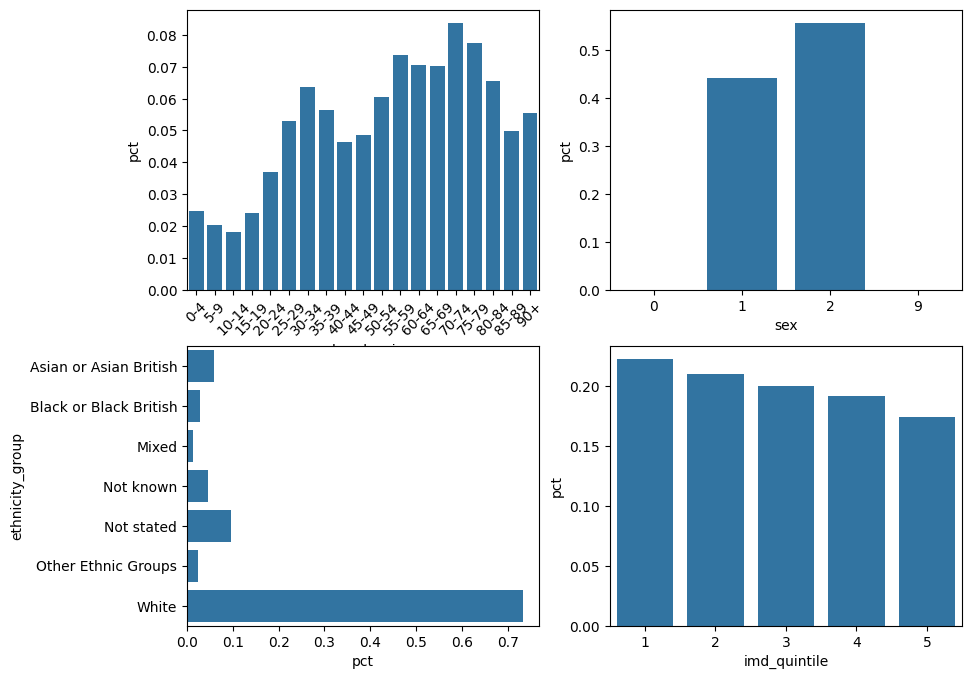

In [33]:
# Demographic splits
age_df = df["age_band_quinary"].value_counts(normalize=True).reset_index(name="pct")
sex_df = df["sex"].value_counts(normalize=True).reset_index(name="pct")
eth_df = df["ethnicity_group"].value_counts(normalize=True).reset_index(name="pct")
imd_df = df["imd_quintile"].value_counts(normalize=True).reset_index(name="pct")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.barplot(data=age_df, x="age_band_quinary", y="pct", ax=axes[0, 0])
axes[0, 0].tick_params(axis="x", rotation=45)
sns.barplot(data=sex_df, x="sex", y="pct", ax=axes[0, 1])
sns.barplot(data=eth_df, y="ethnicity_group", x="pct", ax=axes[1, 0])
sns.barplot(data=imd_df, x="imd_quintile", y="pct", ax=axes[1, 1])

Text(0.5, 1.0, 'Mean LOS by IMD Quintile')

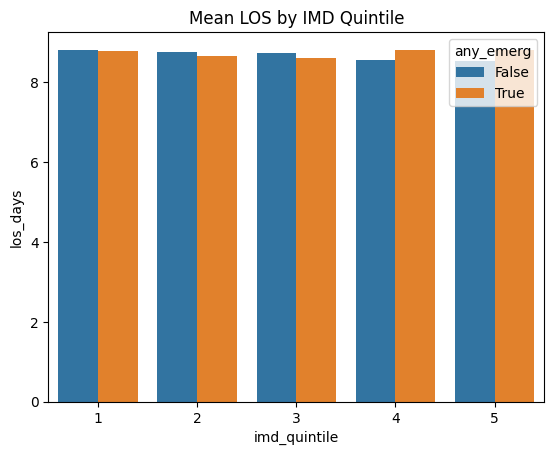

In [34]:
# Avg LOS IMD
los_by_ethnicity = df.groupby(["imd_quintile", "any_emerg"], observed=False)["los_days"].mean().reset_index()

sns.barplot(los_by_ethnicity, x="imd_quintile", y="los_days", hue="any_emerg")

plt.title("Mean LOS by IMD Quintile")

Text(0.5, 1.0, 'Mean LOS by Ethnicity Group')

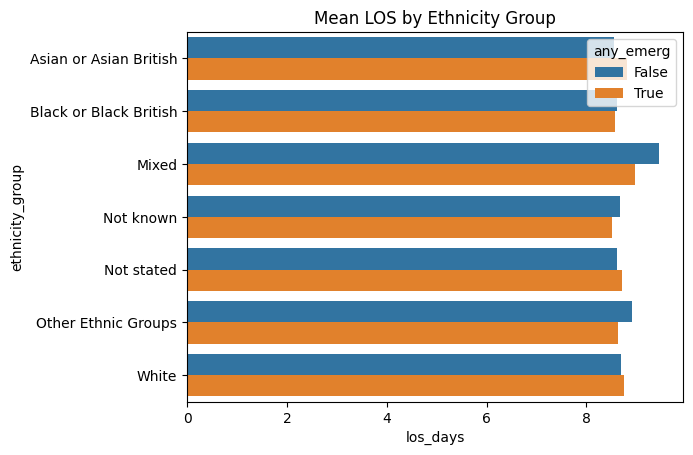

In [35]:
# Avg LOS ethnicity
los_by_ethnicity = df.groupby(["ethnicity_group", "any_emerg"], observed=False)["los_days"].mean().reset_index()

sns.barplot(los_by_ethnicity, y="ethnicity_group", x="los_days", hue="any_emerg")

plt.title("Mean LOS by Ethnicity Group")

Text(0.5, 1.0, 'Respiratory Conditions Distribution')

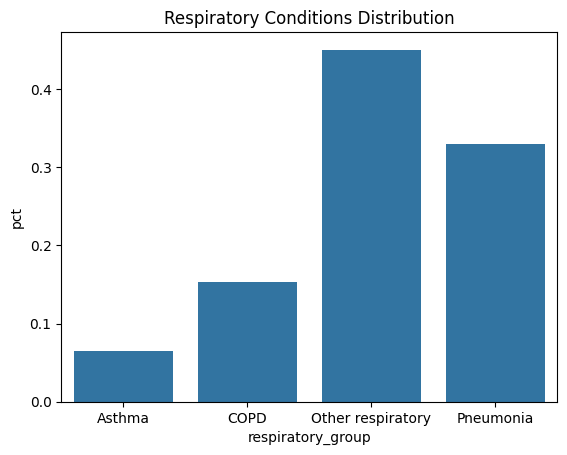

In [36]:
# Distribution of conditions
resp_group = df["respiratory_group"].value_counts(normalize=True).reset_index(name="pct")

sns.barplot(data=resp_group, x="respiratory_group", y="pct")

plt.title("Respiratory Conditions Distribution")

Text(0.5, 1.0, 'LOS by Respiratory Group')

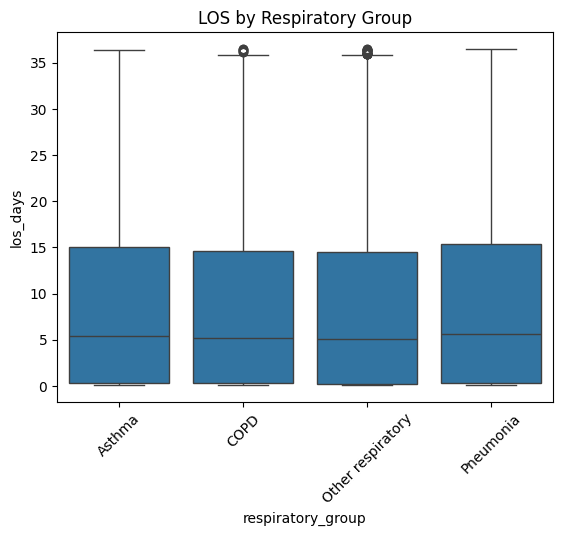

In [37]:
# LOS by condition group
sns.boxplot(x="respiratory_group", y="los_days", data=df)

plt.xticks(rotation=45)
plt.title("LOS by Respiratory Group")

Text(0.5, 1.0, 'LOS by IMD Quintile')

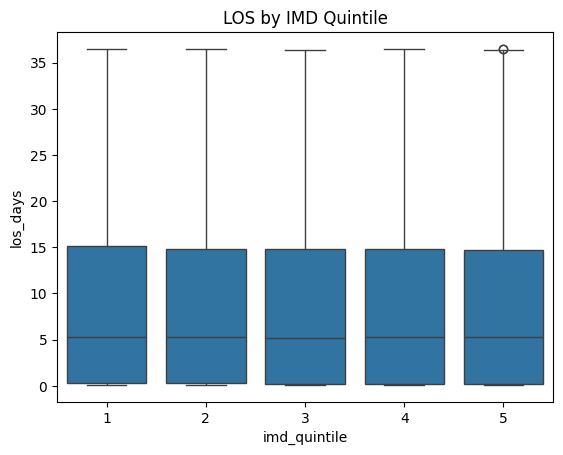

In [38]:
# LOS by IMD
sns.boxplot(data=df, x="imd_quintile", y="los_days")

plt.title("LOS by IMD Quintile")

**Inferential tests for significance checks**

In [39]:
# Test results store
results = []

# LOS and respiratory_group: Kruskal–Wallis
groups = [g["los_days"].dropna() for _, g in df.groupby("respiratory_group", observed=False) if g["los_days"].notna().any()]
stat, p = kruskal(*groups)
results.append({
    "Hypothesis": "LOS differs by respiratory group",
    "Test": "Kruskal–Wallis",
    "Statistic": stat,
    "p-value": p
})

# Age and respiratory_group: Kruskal–Wallis
groups = [g["age"].dropna() for _, g in df.groupby("respiratory_group", observed=False) if g["age"].notna().any()]
stat, p = kruskal(*groups)
results.append({
    "Hypothesis": "Age differs by respiratory group",
    "Test": "Kruskal–Wallis",
    "Statistic": stat,
    "p-value": p
})

# Emergency and Diagnosis: Chi-squared
cont = pd.crosstab(df["respiratory_group"], df["any_emerg"])
chi2, p, dof, exp = chi2_contingency(cont)
results.append({
    "Hypothesis": "Emergency rate differs by diagnosis",
    "Test": "Chi-squared",
    "Statistic": chi2,
    "p-value": p
})

# Admissions per patient and IMD quintile: Kruskal–Wallis
adm_per_patient = (
    df.groupby(["patient_id", "imd_quintile"], observed=False)["spell_id"]
      .count()
      .reset_index(name="n_adm")
)
groups = [g["n_adm"] for _, g in adm_per_patient.groupby("imd_quintile", observed=False)]
stat, p = kruskal(*groups)
results.append({
    "Hypothesis": "Admissions per patient differ by deprivation quintile",
    "Test": "Kruskal–Wallis",
    "Statistic": stat,
    "p-value": p
})

# Compile results
inferential_summary = pd.DataFrame(results)
inferential_summary["Significant (<0.05)"] = inferential_summary["p-value"] < 0.05

print("\nSummary:")
print(inferential_summary.to_markdown(index=False))


Summary:
| Hypothesis                                            | Test           |   Statistic |     p-value | Significant (<0.05)   |
|:------------------------------------------------------|:---------------|------------:|------------:|:----------------------|
| LOS differs by respiratory group                      | Kruskal–Wallis |    44.4097  | 1.23513e-09 | True                  |
| Age differs by respiratory group                      | Kruskal–Wallis |     3.58581 | 0.309802    | False                 |
| Emergency rate differs by diagnosis                   | Chi-squared    |     3.31059 | 0.346171    | False                 |
| Admissions per patient differ by deprivation quintile | Kruskal–Wallis |    20.643   | 0.000372671 | True                  |


**END**